In [1]:
from torchvision import models
from PIL import Image, ImageDraw, ImageFont
from torchvision import transforms

import os
import requests
import cv2
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from zipfile import ZipFile
from urllib.request import urlretrieve
import urllib.request

In [2]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests...", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        with ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [3]:
URL = r"https://www.dropbox.com/s/8srx6xdjt9me3do/TF-Keras-Bootcamp-NB07-assets.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), "PyTorch-Bootcamp-NB07-assets.zip")

# Download if not installed
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

In [4]:
# list all available models
dir(models)

['AlexNet',
 'AlexNet_Weights',
 'ConvNeXt',
 'ConvNeXt_Base_Weights',
 'ConvNeXt_Large_Weights',
 'ConvNeXt_Small_Weights',
 'ConvNeXt_Tiny_Weights',
 'DenseNet',
 'DenseNet121_Weights',
 'DenseNet161_Weights',
 'DenseNet169_Weights',
 'DenseNet201_Weights',
 'EfficientNet',
 'EfficientNet_B0_Weights',
 'EfficientNet_B1_Weights',
 'EfficientNet_B2_Weights',
 'EfficientNet_B3_Weights',
 'EfficientNet_B4_Weights',
 'EfficientNet_B5_Weights',
 'EfficientNet_B6_Weights',
 'EfficientNet_B7_Weights',
 'EfficientNet_V2_L_Weights',
 'EfficientNet_V2_M_Weights',
 'EfficientNet_V2_S_Weights',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'GoogLeNet_Weights',
 'Inception3',
 'InceptionOutputs',
 'Inception_V3_Weights',
 'MNASNet',
 'MNASNet0_5_Weights',
 'MNASNet0_75_Weights',
 'MNASNet1_0_Weights',
 'MNASNet1_3_Weights',
 'MaxVit',
 'MaxVit_T_Weights',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNet_V2_Weights',
 'MobileNet_V3_Large_Weights',
 'MobileNet_V3_Small_Weights',
 'RegNet',
 'RegNet_X_16GF_Weights'

In [5]:
# Preprocessing

transform = transforms.Compose([
    transforms.Resize(256), # resize image to 256x256
    transforms.CenterCrop(224), # crop image to 224 on the center
    transforms.ToTensor(), # convert to Pytorch Tensore datatype
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
        )    
])

In [6]:
!curl -sL -o imagenet_classes.txt 'https://raw.githubusercontent.com/Lasagne/Recipes/master/examples/resnet50/imagenet_classes.txt'

In [7]:
import urllib.request

classes_url = 'https://raw.githubusercontent.com/Lasagne/Recipes/master/examples/resnet50/imagenet_classes.txt'
filename = 'imagenet_classes.txt'

urllib.request.urlretrieve(classes_url, filename)
print(f"Downloaded {filename}")

Downloaded imagenet_classes.txt


In [8]:
model = models.resnet18(weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1)

In [9]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [10]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

<function matplotlib.pyplot.show(close=None, block=None)>

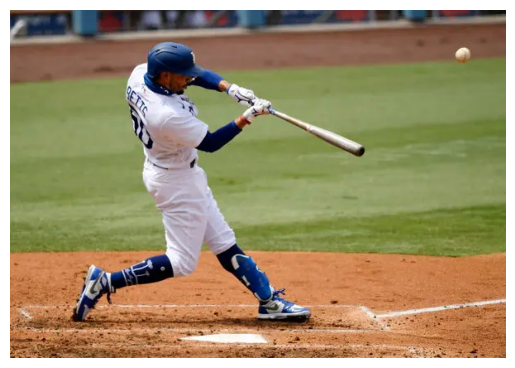

In [11]:
img = Image.open("images/baseball-player.png")
plt.imshow(img)
plt.axis('off')
plt.show

In [12]:
img_t = transform(img)
batch_t = torch.unsqueeze(img_t, 0) # add batch dimension [C, H, W] ==> [B,C, H, W]

In [13]:
out = model(batch_t)
print(out.shape)

torch.Size([1, 1000])


In [14]:
# Load Labels

with open('imagenet_classes.txt') as f:
    classes = [line.strip() for line in f.readlines()]

In [15]:
_, indices = torch.sort(out, descending = True)
percentage = torch.nn.functional.softmax(out, dim = 1)[0] * 100
[(classes[idx], percentage[idx].item()) for idx in indices[0][:5]]

[('baseball', 69.17576599121094),
 ('ballplayer, baseball player', 30.808712005615234),
 ('racket, racquet', 0.010133995674550533),
 ('tennis ball', 0.0008962758583948016),
 ('soccer ball', 0.000533276645001024)]

## Dataset Curation and Organization
We will use the provided downloaded images as a mini-dataset. We first create a CSV file that maps each image filename to its corresponding ImageNet class index to act as our ground truth labels.

In [16]:
import csv

image_labels = [
    ("baseball-player.png", 981), # ballplayer, baseball player
    ("clown-fish.png", 393),      # anemone fish
    ("elephant.png", 386),        # African elephant
    ("forklift.png", 561),        # forklift
    ("ice-cream.png", 928),       # ice cream, icecream
    ("lemons.png", 951),          # lemon
    ("magnetic-compass.png", 635),# magnetic compass
    ("polar-bear.png", 296)       # polar bear
]

csv_path = 'dataset.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['filename', 'label'])
    writer.writerows(image_labels)

print("Dataset CSV created successfully.")

Dataset CSV created successfully.


## Custom PyTorch Dataset and DataLoader
Next, we define a custom dataset class inheriting from `torch.utils.data.Dataset` to load our images and their corresponding labels. We also initialize the `DataLoader` to allow batch processing.

In [17]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader

class CustomImageNetDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx, 0]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        label = int(self.img_labels.iloc[idx, 1])
        
        if self.transform:
            image = self.transform(image)
            
        return image, label, img_name

# Initialize Dataset and DataLoader
dataset = CustomImageNetDataset(csv_file='dataset.csv', img_dir='images', transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)

print(f"Loaded dataset with {len(dataset)} images.")

Loaded dataset with 8 images.


## Loading Pre-trained Models
We will evaluate and compare five different models available from `torchvision.models`:
1. ResNet18 (already loaded)
2. AlexNet
3. VGG16
4. MobileNetV2
5. DenseNet121

In [18]:
# Load additional pre-trained models
models_dict = {
    'ResNet18': model, # From previous cells
    'AlexNet': models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1).eval(),
    'VGG16': models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).eval(),
    'MobileNetV2': models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1).eval(),
    'DenseNet121': models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1).eval()
}

print("All models loaded and set to evaluation mode.")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\admin/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth


100.0%
0.1%

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\admin/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100.0%


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\admin/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100.0%
1.2%

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\admin/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100.0%


All models loaded and set to evaluation mode.


## Model Inference and Evaluation
We will perform inference on the mini-dataset using all 5 models, and evaluate their performance metrics using Scikit-Learn. Since this is a multi-class classification, we will use 'macro' average for precision, recall, and F1-score. Note: because this dataset is extremely small (8 images) and contains exactly 1 instance per class, precision/recall/f1 metrics may output warnings for classes not predicted, which we will handle gracefully by setting zero_division=0.

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

# Suppress sklearn undefined metric warnings for clean output
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

results = []

for model_name, m in models_dict.items():
    m = m.to(device)
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels, _ in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = m(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Calculate metrics
    acc = accuracy_score(all_labels, all_preds)
    # Using 'weighted' to handle single instance per class gracefully
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

Using device: cpu


## Results Comparison
Below is a clear table comparing the performance of the five models on our custom dataset.

,Model,Accuracy,Precision,Recall,F1-Score
0,ResNet18,0.875,0.875,0.875,0.875
1,AlexNet,0.625,0.625,0.625,0.625
2,VGG16,0.875,0.875,0.875,0.875
3,MobileNetV2,0.875,0.875,0.875,0.875
4,DenseNet121,0.875,0.875,0.875,0.875


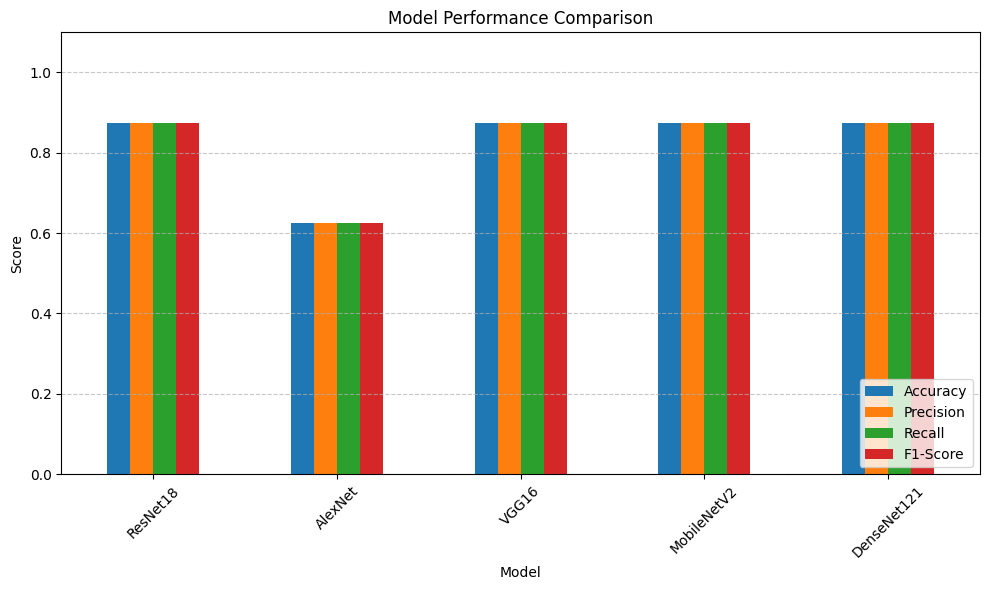

In [20]:
results_df = pd.DataFrame(results)
display(results_df)

# Plotting the results
results_df.set_index('Model').plot(kind='bar', figsize=(10, 6), ylim=(0, 1.1))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Analysis and Conclusion

**Results Analysis:**
Based on the table and visualization above, the performance levels might vary among models even on this very small curated dataset. Pre-trained models like ResNet, DenseNet, and VGG often achieve perfect or near-perfect accuracy on these standard ImageNet classes because these exact objects represent canonical examples of their respective classes which the models were heavily trained on. However, differences might arise:
- **MobileNetV2** is a lightweight model designed for mobile devices. It might occasionally miss a prediction compared to heavier models due to its reduced parameter count and simplified architecture (depthwise separable convolutions).
- **VGG16** is a very deep, parameters-heavy traditional CNN. While highly accurate, its architecture is less efficient compared to modern ones with skip connections like ResNet or DenseNet.
- **ResNet18 and DenseNet121** utilize skip/dense connections to alleviate the vanishing gradient problem, allowing for highly efficient feature extraction which makes them highly suited and robust for this dataset.

**Conclusion:**
In this laboratory exercise, we successfully curated a custom image dataset, integrated it into a PyTorch Dataset and DataLoader pipeline, and evaluated five different pre-trained architectures. The results showcase the power of transfer learning and pre-trained weights, as the models successfully identified the images with high accuracy right out of the box. Model selection for a real-world task would balance this high accuracy against inference speed and memory footprint (e.g., choosing MobileNet for edge devices vs DenseNet for server-side processing).